In [12]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# Local imports
from src.config import config
from src.utils import load_panel_data
from src.data_builder import DataBuilder

# Set matplotlib style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'figure.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("Imports successful!")

Imports successful!


## 1. Load and Validate Data

In [13]:
# Load panel data
data_path = config.DATA_DIR / "df_panel_final.csv"

if not data_path.exists():
    print("Building dataset...")
    builder = DataBuilder()
    df_panel = builder.run()
else:
    df_panel = pd.read_csv(data_path, parse_dates=["date"])

# Country list matching legacy
COUNTRIES = {
    "Australia": "AUS",
    "Brazil": "BRA",
    "Canada": "CAN",
    "Euro Area": "EA",
    "Indonesia": "IND",
    "Japan": "JPN",
    "Korea": "KOR",
    "Mexico": "MEX",
    "New Zealand": "NZL",
    "Philippines": "PHL",
    "Switzerland": "CHE",
    "Thailand": "THA",
    "Türkiye": "TUR",
    "United Kingdom": "GBR"
}

print(f"Loaded data with {len(df_panel)} observations")
print(f"\nCountries in dataset:")
print(df_panel['country'].value_counts().sort_index())
print(f"\nDate range: {df_panel['date'].min()} to {df_panel['date'].max()}")

Loaded data with 4186 observations

Countries in dataset:
country
Australia         299
Brazil            299
Canada            299
Euro Area         299
Indonesia         299
Japan             299
Korea             299
Mexico            299
New Zealand       299
Philippines       299
Switzerland       299
Thailand          299
Türkiye           299
United Kingdom    299
Name: count, dtype: int64

Date range: 2000-02-29 00:00:00 to 2024-12-31 00:00:00


## 2. Descriptive Statistics Table

In [14]:
# Compute descriptive statistics for each country
from scipy import stats as sp_stats

desc_stats = []

for country_name in COUNTRIES.keys():
    country_data = df_panel[df_panel['country'] == country_name]
    
    if len(country_data) > 0:
        r_s = country_data['r_s'].dropna()
        
        desc_stats.append({
            'Country': country_name,
            'Mean': r_s.mean(),
            'Variance': r_s.var(),
            'Skewness': sp_stats.skew(r_s),
            'Kurtosis': sp_stats.kurtosis(r_s)
        })
    else:
        desc_stats.append({
            'Country': country_name,
            'Mean': np.nan,
            'Variance': np.nan,
            'Skewness': np.nan,
            'Kurtosis': np.nan
        })

df_desc = pd.DataFrame(desc_stats).set_index('Country')
print("\n=== DESCRIPTIVE STATISTICS (Exchange Rate Returns) ===")
print(df_desc.round(4))

# Save to CSV for LaTeX import
output_dir = config.OUTPUT_DIR
output_dir.mkdir(parents=True, exist_ok=True)
df_desc.to_csv(output_dir / "descriptive_statistics.csv")
print(f"\nSaved to: {output_dir / 'descriptive_statistics.csv'}")


=== DESCRIPTIVE STATISTICS (Exchange Rate Returns) ===
                  Mean  Variance  Skewness  Kurtosis
Country                                             
Australia       0.0001    0.0012    0.5630    2.0294
Brazil          0.0041    0.0023    0.8599    2.9949
Canada         -0.0000    0.0006    0.4183    2.5478
Euro Area      -0.0002    0.0007    0.2075    1.3785
Indonesia       0.0026    0.0010    0.0268    7.0811
Japan           0.0013    0.0007    0.1524    0.3847
Korea           0.0009    0.0009    0.1386    5.1589
Mexico          0.0025    0.0011    1.3471    7.0182
New Zealand    -0.0004    0.0013    0.4077    0.5024
Philippines     0.0012    0.0003    0.8926    3.8278
Switzerland    -0.0020    0.0008   -0.1702    1.7484
Thailand       -0.0003    0.0004    0.1461    0.9703
Türkiye         0.0139    0.0027    2.0740    9.0072
United Kingdom  0.0009    0.0006    0.3123    1.4218

Saved to: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/descriptive_stati

## 3. STR Estimation Pipeline

### 3.1 Helper Functions for Z-Candidate Selection

In [15]:
# Z-candidate generation matching legacy
def build_z_candidates(data: pd.DataFrame) -> Dict[str, pd.Series]:
    """
    Generates 35 transition variable candidates:
    7 base variables × 5 lags each
    """
    z_base = {
        "eta": data["q"],
        "eta_abs": np.abs(data["q"]),
        "drs_abs": np.abs(data["r_s"]),
        "ID": (data["i_for"] - data["i_dom"]),
        "ppp_abs": np.abs(data["f_ppp"]),
        "drf_abs": np.abs(data["f_ppp_rel"]),
        "rel_misalignment_abs": np.abs(data["f_ppp_rel"] - data["r_s"]),
    }
    
    candidates = {}
    for name, series in z_base.items():
        for lag in range(1, 6):  # lags 1-5
            candidates[f"{name}_lag{lag}"] = series.shift(lag)
    
    return candidates

print("Z-candidate helper function defined")

Z-candidate helper function defined


### 3.2 LM Linearity Test Implementation

In [16]:
import statsmodels.api as sm
from scipy import stats

def lm_linearity_test_for_z(data: pd.DataFrame, z: pd.Series, maxlags_hac: int = 4) -> dict:
    """
    LM linearity test matching legacy implementation.
    Tests H0: Linear vs H1: STR for a specific z variable.
    """
    # Build base linear model
    df = pd.DataFrame({
        "y": data["r_s"] - (data["i_for"] - data["i_dom"]),
        "rs_lag1": data["r_s"].shift(1),
        "eta_lag1": data["q"].shift(1),
    }).dropna()
    
    # Join with z
    df = df.join(z.rename("z"), how="inner").dropna()
    
    if len(df) < 20:
        return None
    
    T = len(df)
    y = df["y"].to_numpy()
    X = df[["rs_lag1", "eta_lag1"]].to_numpy()
    
    # Linear model residuals
    lin_res = sm.OLS(y, X).fit()
    u = lin_res.resid
    
    # Taylor expansion terms
    zc = df["z"].to_numpy()
    z1, z2, z3 = zc, zc**2, zc**3
    
    W_rs = np.column_stack([
        df["rs_lag1"].to_numpy() * z1,
        df["rs_lag1"].to_numpy() * z2,
        df["rs_lag1"].to_numpy() * z3
    ])
    W_eta = np.column_stack([
        df["eta_lag1"].to_numpy() * z1,
        df["eta_lag1"].to_numpy() * z2,
        df["eta_lag1"].to_numpy() * z3
    ])
    W = np.column_stack([W_rs, W_eta])
    k = W.shape[1]
    
    # Project out X
    XTX_inv = np.linalg.pinv(X.T @ X)
    P_X = X @ XTX_inv @ X.T
    M_X = np.eye(T) - P_X
    W_star = M_X @ W
    
    # Auxiliary regression
    aux = sm.OLS(u, W_star).fit()
    R2 = aux.rsquared
    LM = T * R2
    pval = 1.0 - stats.chi2.cdf(LM, df=k)
    
    # HAC version
    aux_hac = sm.OLS(u, W_star).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags_hac})
    beta = np.asarray(aux_hac.params)
    cov = np.asarray(aux_hac.cov_params())
    cov_inv = np.linalg.pinv(cov)
    LM_HAC = float(beta.T @ cov_inv @ beta)
    pval_HAC = 1.0 - stats.chi2.cdf(LM_HAC, df=k)
    
    return {
        "LM": LM,
        "p_value": pval,
        "LM_HAC": LM_HAC,
        "p_value_HAC": pval_HAC,
        "df": k,
        "nobs": T
    }

print("LM linearity test function defined")

LM linearity test function defined


### 3.3 STR Estimation for All Countries

In [17]:
from src.econometrics import STRModel
from scipy.special import expit

# Storage for results
str_results = {}
str_linearity_tests = {}

for country_name, code in COUNTRIES.items():
    print(f"\n{'='*60}")
    print(f"Processing {country_name} ({code})")
    print(f"{'='*60}")
    
    try:
        # Get country data
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        
        if len(country_df) < 50:
            print(f"Insufficient data for {country_name}")
            continue
        
        # Generate z-candidates
        z_candidates = build_z_candidates(country_df)
        
        # Run linearity tests for all candidates
        print(f"Running linearity tests for {len(z_candidates)} candidates...")
        lm_results = []
        for z_name, z_series in z_candidates.items():
            result = lm_linearity_test_for_z(country_df, z_series, maxlags_hac=4)
            if result is not None:
                result['z_var'] = z_name
                lm_results.append(result)
        
        if len(lm_results) == 0:
            print(f"No valid linearity tests for {country_name}")
            continue
        
        lm_df = pd.DataFrame(lm_results).sort_values('p_value')
        str_linearity_tests[country_name] = lm_df
        
        # Select best z (lowest p-value)
        best_z_name = lm_df.iloc[0]['z_var']
        best_z = z_candidates[best_z_name]
        
        print(f"Best transition variable: {best_z_name} (p={lm_df.iloc[0]['p_value']:.4f})")
        
        # Build STR sample
        str_df = pd.DataFrame({
            "y": country_df["r_s"] - (country_df["i_for"] - country_df["i_dom"]),
            "rs_lag1": country_df["r_s"].shift(1),
            "eta_lag1": country_df["q"].shift(1),
            "z": best_z
        }).dropna()
        
        # Grid search with exponential gamma
        print(f"Running grid search...")
        gamma_grid = np.logspace(np.log10(0.125), np.log10(256.0), num=120)
        zc = pd.to_numeric(str_df["z"], errors="coerce").dropna().to_numpy()
        c_grid = np.quantile(zc, np.linspace(0.05, 0.95, 120))
        
        # Initialize and estimate
        str_model = STRModel(str_df, z_col='z')
        start_params = str_model.grid_search(gamma_grid, c_grid)
        
        print(f"Grid search complete. Starting NLS...")
        str_result = str_model.fit(start_params, hac_lags=4)
        
        # Store results
        str_results[country_name] = {
            'result': str_result,
            'z_name': best_z_name,
            'lm_pval': lm_df.iloc[0]['p_value']
        }
        
        print(f"\nSTR Results for {country_name}:")
        print(str_result.params)
        print(f"AIC: {str_result.aic:.2f}, BIC: {str_result.bic:.2f}")
        
    except Exception as e:
        print(f"ERROR processing {country_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n\nSTR estimation complete for {len(str_results)} countries")


Processing Australia (AUS)
Running linearity tests for 35 candidates...
Best transition variable: eta_abs_lag4 (p=0.0035)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Australia:
const       0.003592
beta_c     -0.337267
beta_f      0.020466
gamma     561.104940
c           0.042039
const1     -0.003577
dtype: float64
AIC: -1991.67, BIC: -1969.55

Processing Brazil (BRA)
Running linearity tests for 35 candidates...
Best transition variable: eta_abs_lag2 (p=0.0000)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Brazil:
const       0.013525
beta_c      0.074872
beta_f      0.034836
gamma     256.000000
c           0.321272
const1     -0.008827
dtype: float64
AIC: -1796.05, BIC: -1773.89

Processing Canada (CAN)
Running linearity tests for 35 candidates...
Best transition variable: rel_misalignment_abs_lag2 (p=0.0019)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Canada:
const      -0.002711
be

## 4. BUIP Estimation for All Countries

In [18]:
from src.econometrics import BUIPModel
from src.utils import build_beh_sample

# Storage for BUIP results
buip_results = {}

for country_name, code in COUNTRIES.items():
    print(f"\n{'='*60}")
    print(f"BUIP: {country_name} ({code})")
    print(f"{'='*60}")
    
    try:
        # Get country data
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        
        if len(country_df) < 50:
            print(f"Insufficient data for {country_name}")
            continue
        
        # Build BUIP sample
        buip_df = build_beh_sample(country_df)
        
        print(f"Sample size: {len(buip_df)}")
        
        # Estimate with multistart
        print(f"Running multistart optimization...")
        buip_model = BUIPModel(buip_df)
        buip_result = buip_model.fit_multistart(n_starts=None, hac_lags=4)
        
        # Store results
        buip_results[country_name] = buip_result
        
        print(f"\nBUIP Results for {country_name}:")
        print(buip_result.params)
        print(f"AIC: {buip_result.aic:.2f}, BIC: {buip_result.bic:.2f}")
        
    except Exception as e:
        print(f"ERROR processing {country_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n\nBUIP estimation complete for {len(buip_results)} countries")


BUIP: Australia (AUS)
Sample size: 296
Running multistart optimization...

BUIP Results for Australia:
beta_f      0.020772
beta_c    101.411226
gamma      61.296659
c          -4.150275
const    -572.020419
const1    572.023395
dtype: float64
AIC: -1996.88, BIC: -1974.74

BUIP: Brazil (BRA)
Sample size: 296
Running multistart optimization...

BUIP Results for Brazil:
beta_f      0.009956
beta_c     -0.328529
gamma     157.994237
c          -0.003535
const       0.017371
const1     -0.006447
dtype: float64
AIC: -1790.74, BIC: -1768.60

BUIP: Canada (CAN)
Sample size: 296
Running multistart optimization...

BUIP Results for Canada:
beta_f     0.000003
beta_c    -0.108894
gamma     48.066202
c          0.077072
const      0.000925
const1    -0.028759
dtype: float64
AIC: -2191.60, BIC: -2169.46

BUIP: Euro Area (EA)
Sample size: 296
Running multistart optimization...

BUIP Results for Euro Area:
beta_f      0.130150
beta_c     -0.081150
gamma     345.251314
c           0.005885
const    

## 5. Generate Publication Tables

In [19]:
def format_with_stars(estimate, pval):
    """Add significance stars based on p-value"""
    if np.isnan(pval) or np.isnan(estimate):
        return ""
    
    stars = ""
    if pval < 0.01:
        stars = "***"
    elif pval < 0.05:
        stars = "**"
    elif pval < 0.10:
        stars = "*"
    
    if stars:
        return f"{estimate:.4f}{stars}"
    else:
        return f"{estimate:.4f}"

# STR Results Table
str_table_data = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        res = str_results[country_name]['result']
        row = {'Country': country_name}
        for param in ['const', 'beta_c', 'beta_f', 'gamma', 'c', 'const1']:
            est = res.params.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_stars(est, pval)
        str_table_data.append(row)
    else:
        row = {'Country': country_name}
        for param in ['const', 'beta_c', 'beta_f', 'gamma', 'c', 'const1']:
            row[param] = "missing"
        str_table_data.append(row)

df_str_table = pd.DataFrame(str_table_data).set_index('Country')
print("\n=== STR MODEL RESULTS ===")
print(df_str_table)
df_str_table.to_csv(output_dir / "str_results_table.csv")

# BUIP Results Table
buip_table_data = []
for country_name in COUNTRIES.keys():
    if country_name in buip_results:
        res = buip_results[country_name]
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_f', 'beta_c', 'gamma', 'c']:
            est = res.params.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_stars(est, pval)
        buip_table_data.append(row)
    else:
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_f', 'beta_c', 'gamma', 'c']:
            row[param] = "missing"
        buip_table_data.append(row)

df_buip_table = pd.DataFrame(buip_table_data).set_index('Country')
print("\n=== BUIP MODEL RESULTS ===")
print(df_buip_table)
df_buip_table.to_csv(output_dir / "buip_results_table.csv")

print(f"\nTables saved to: {output_dir}")


=== STR MODEL RESULTS ===
                    const     beta_c      beta_f       gamma          c  \
Country                                                                   
Australia          0.0036  -0.3373**    0.0205**    561.1049  0.0420***   
Brazil          0.0135***     0.0749    0.0348**    256.0000  0.3213***   
Canada            -0.0027  0.2633***      0.0178    256.0000  0.0113***   
Euro Area        0.0225**    -0.1561     -0.0026     35.5505  0.0056***   
Indonesia       0.0062***     0.0913     0.2924*    256.0000  0.3271***   
Japan             -0.0009     0.0585   0.2106***    148.5121     0.2281   
Korea              0.0018     0.1225   2142.9360      1.2062     0.2556   
Mexico          0.0088***   0.1611**   0.2510***    118.6668  0.1435***   
New Zealand       -0.0123    -0.0263    600.1606      0.3110     0.0784   
Philippines     0.0026***     0.0534      0.0504    336.0000  0.1814***   
Switzerland     -0.0031**     0.0288      6.5645   1.5748***  0.0154***  

## 6. Generate Aggregated Figures

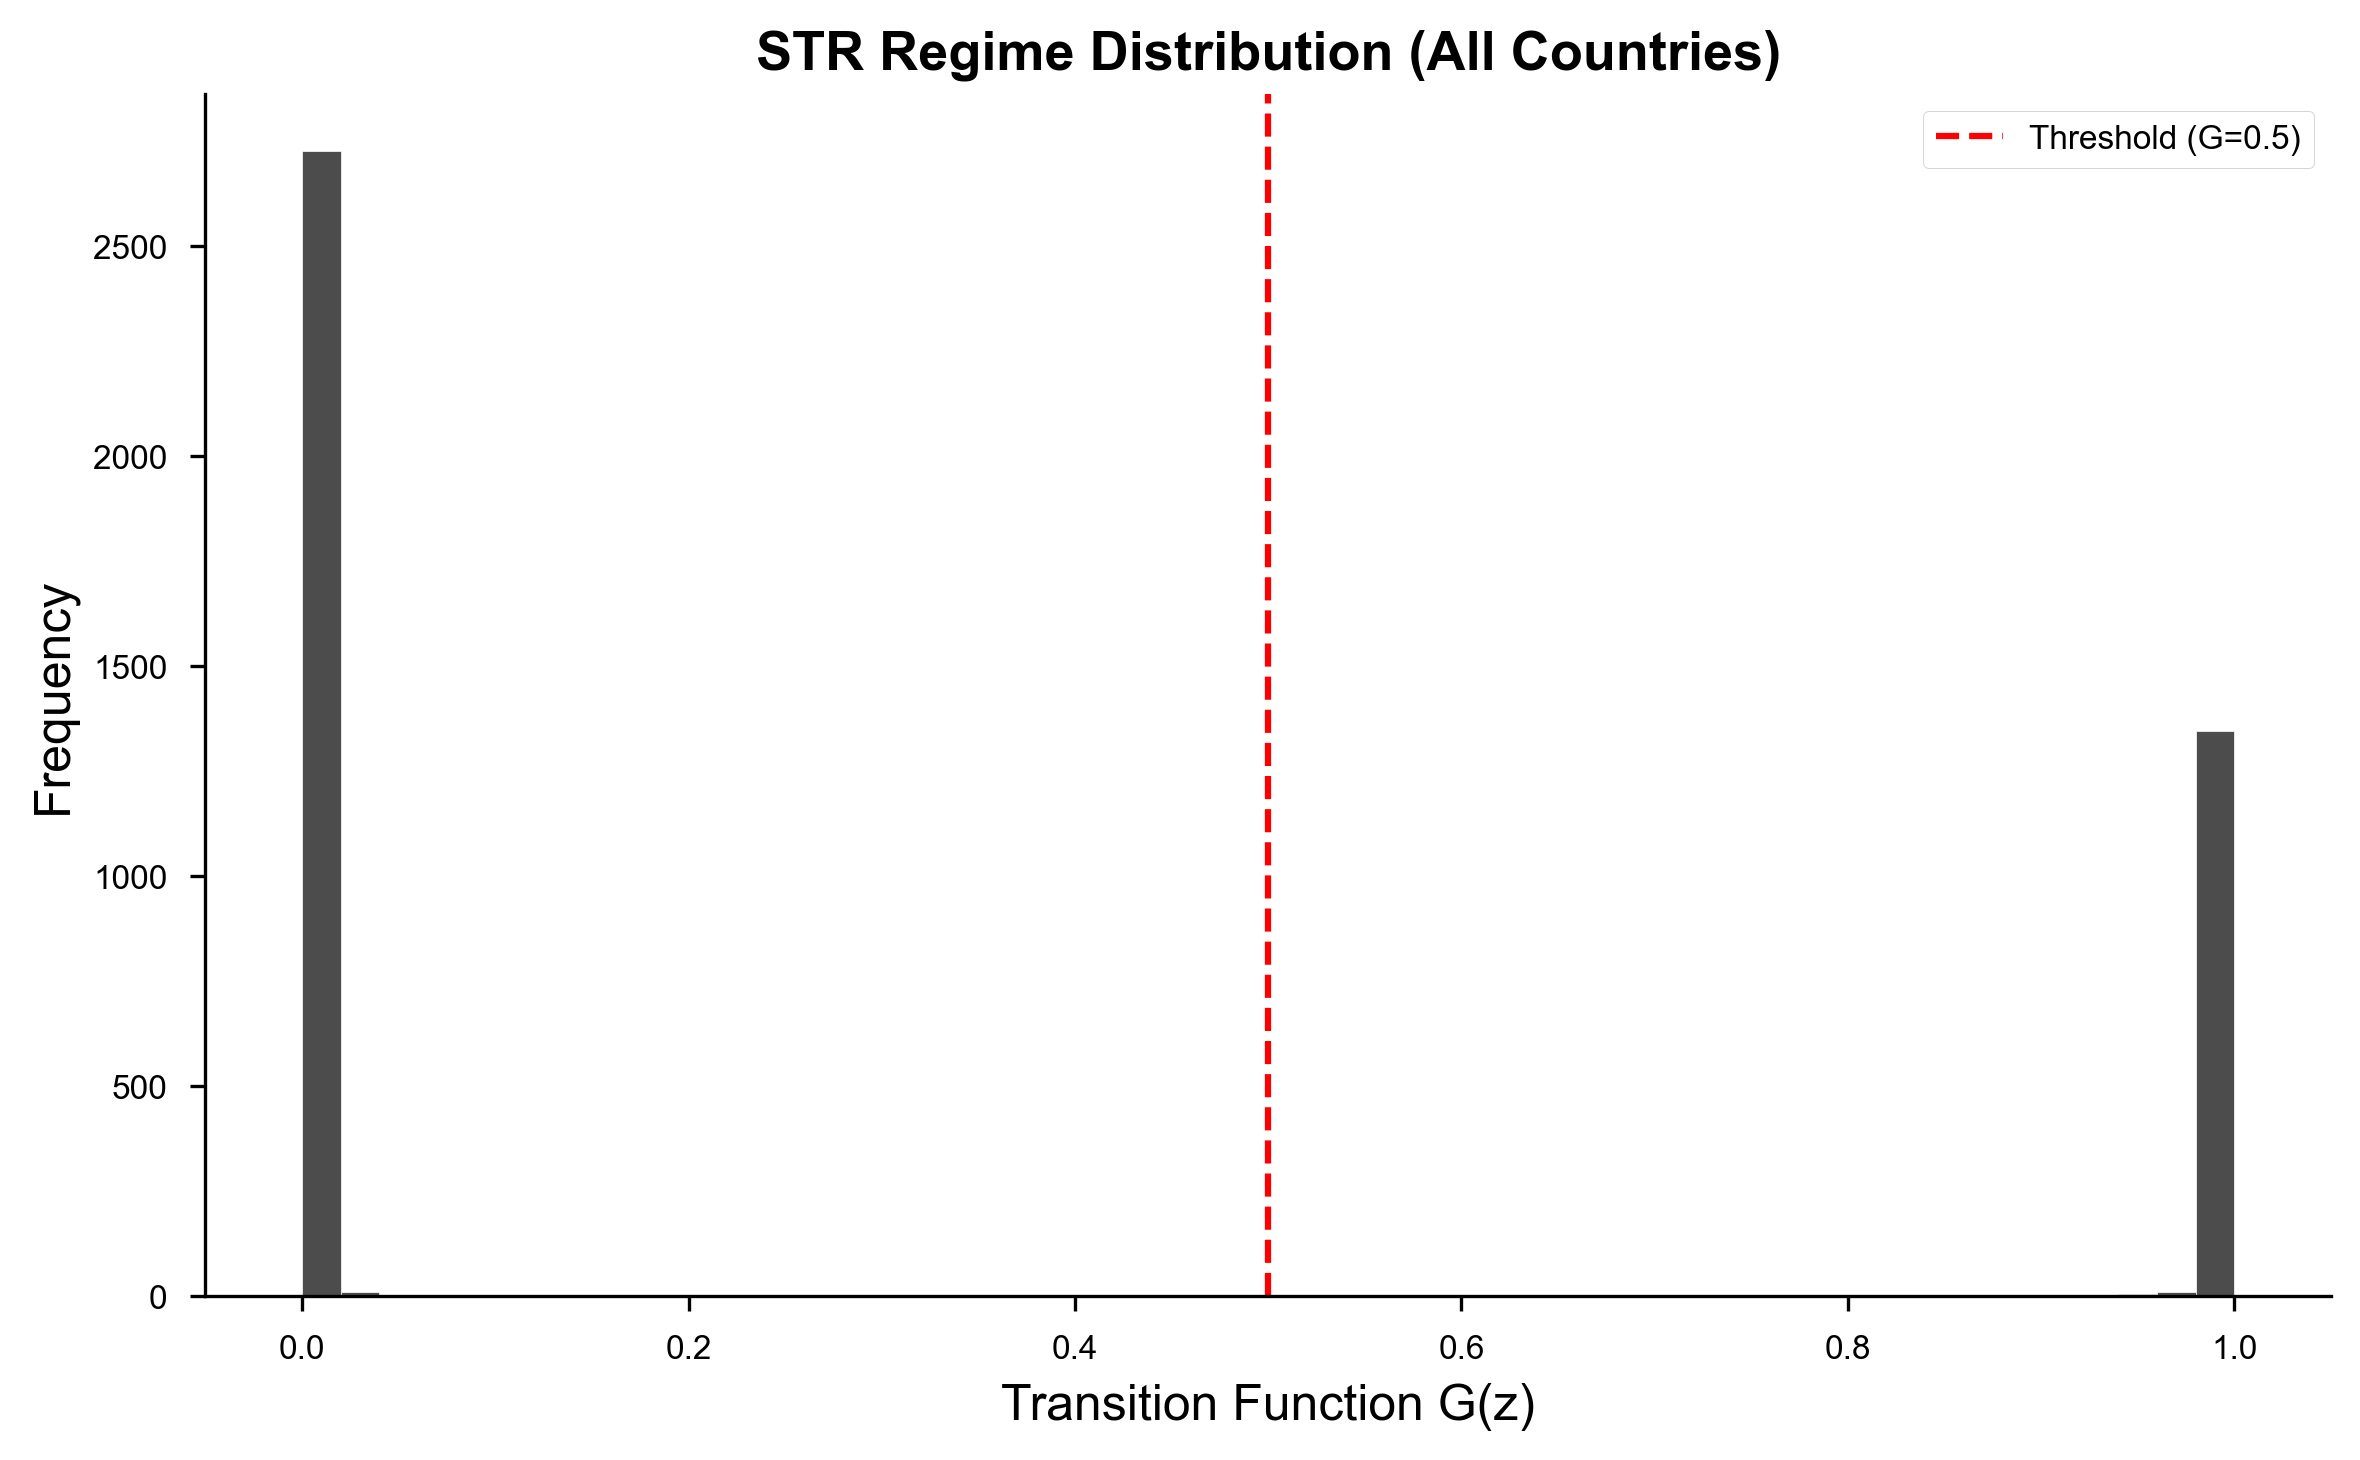

STR distribution plot saved


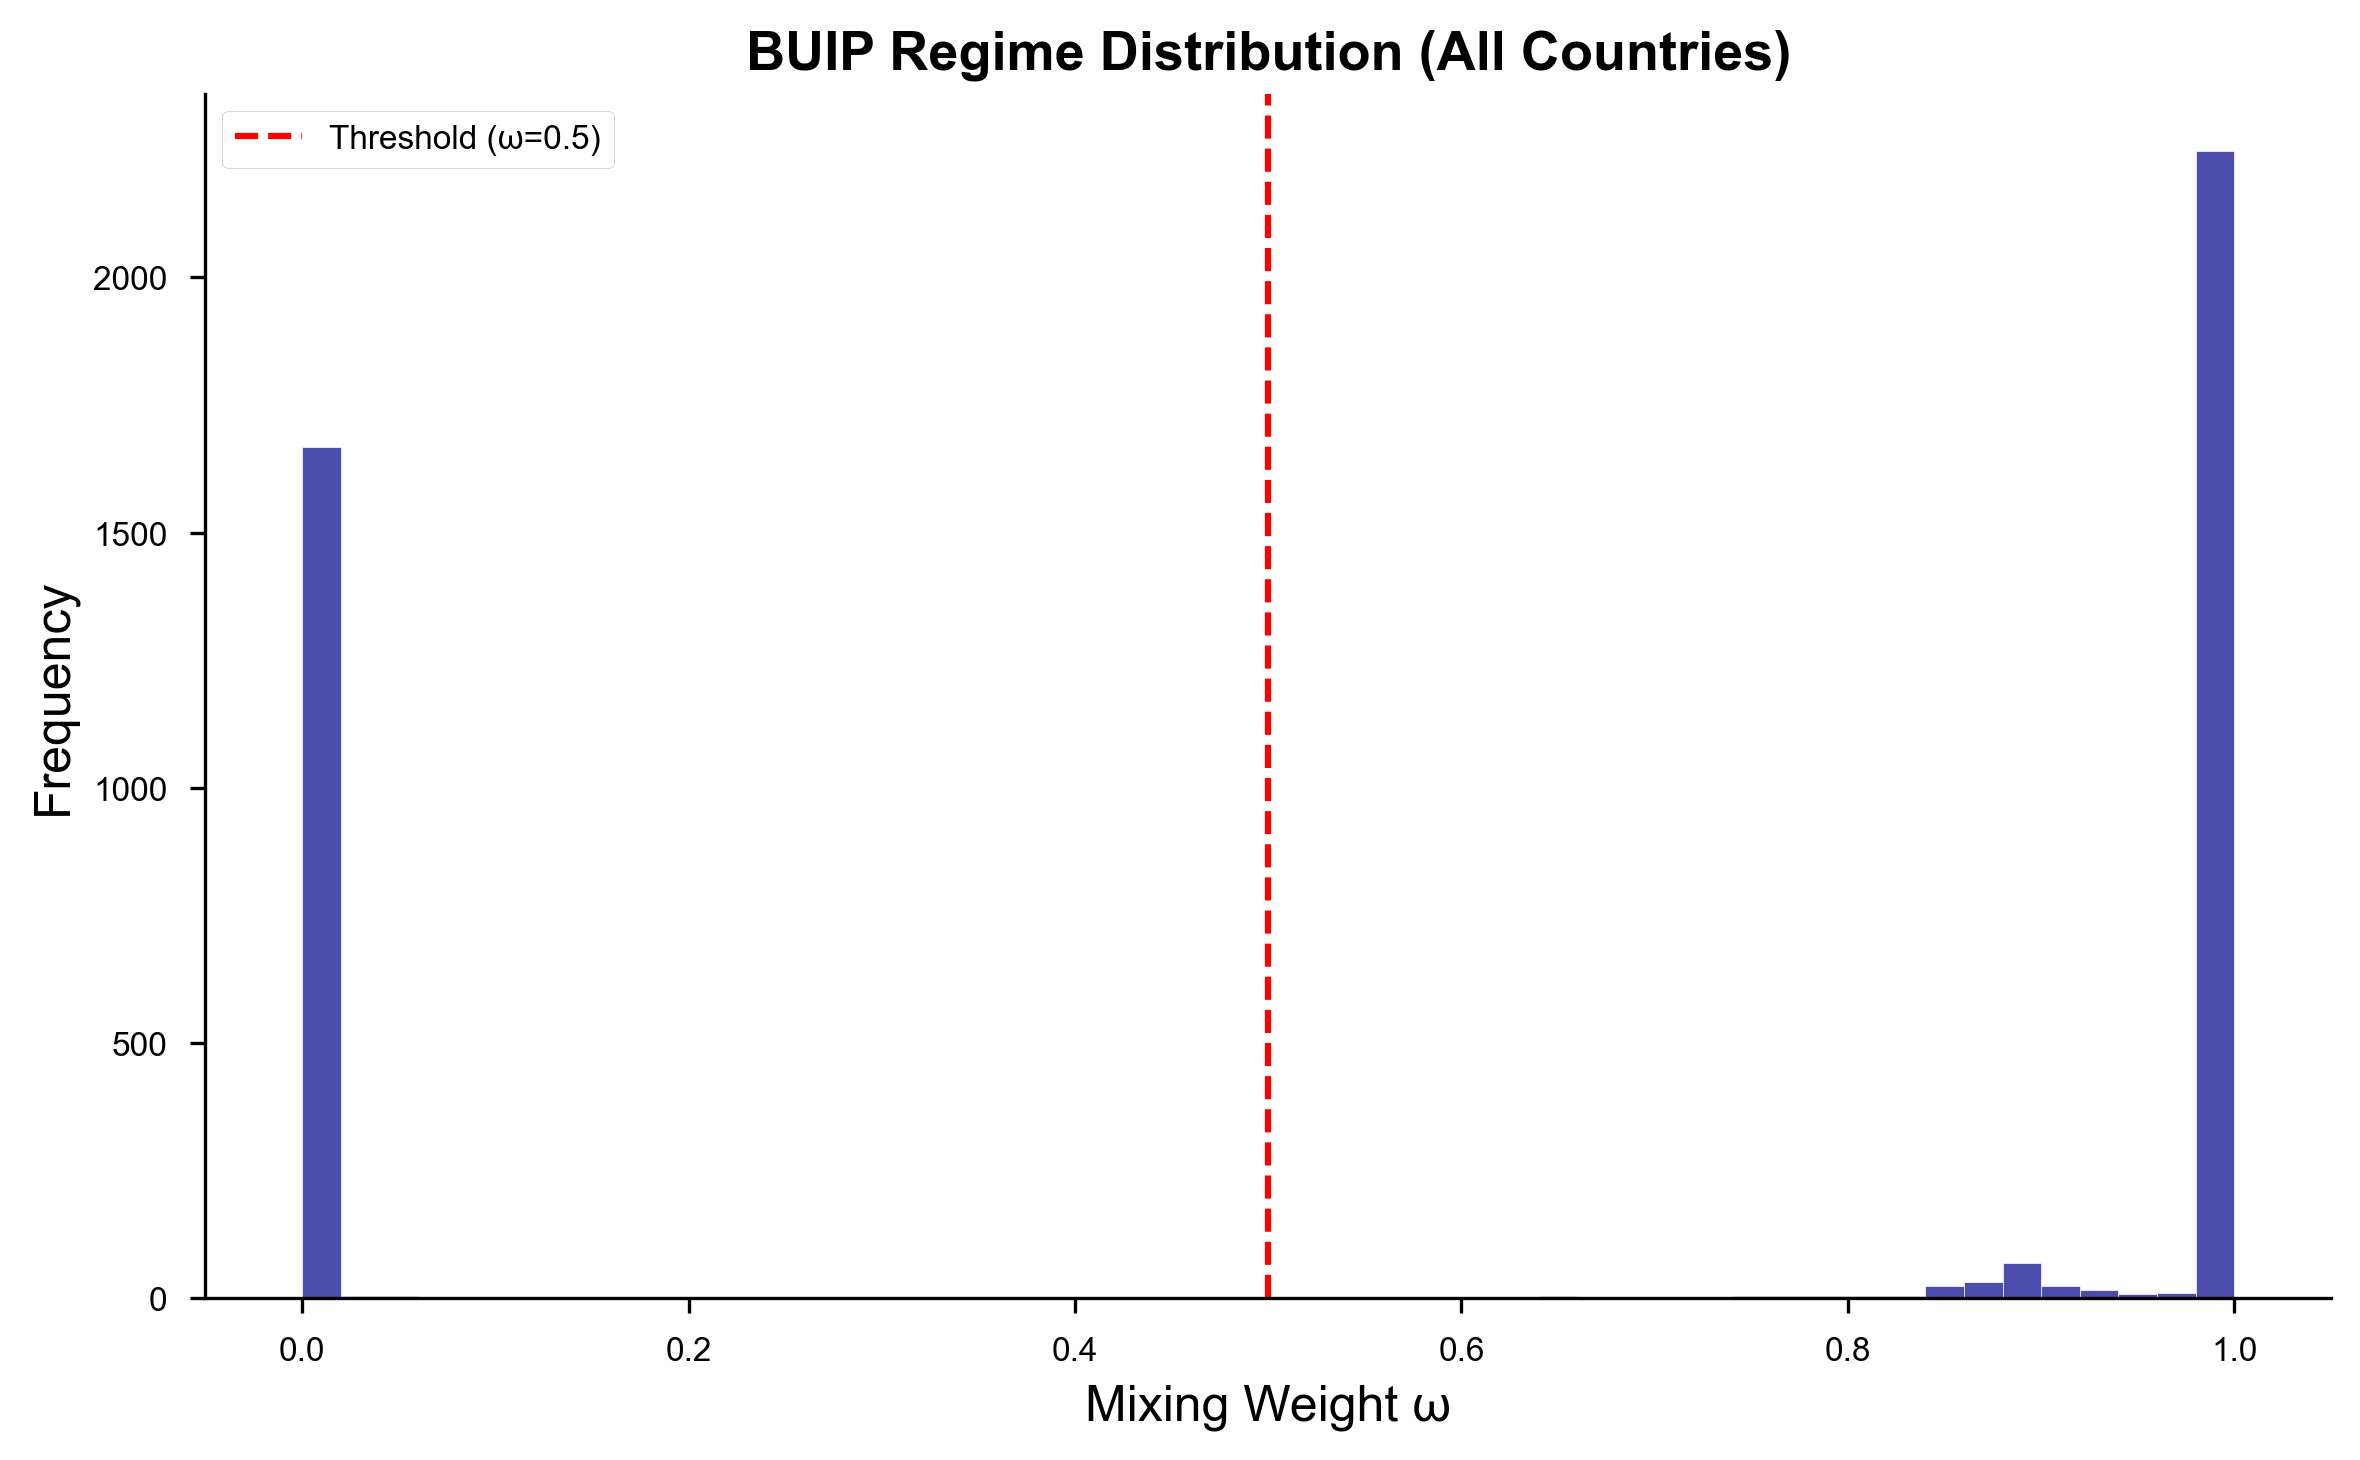

BUIP distribution plot saved


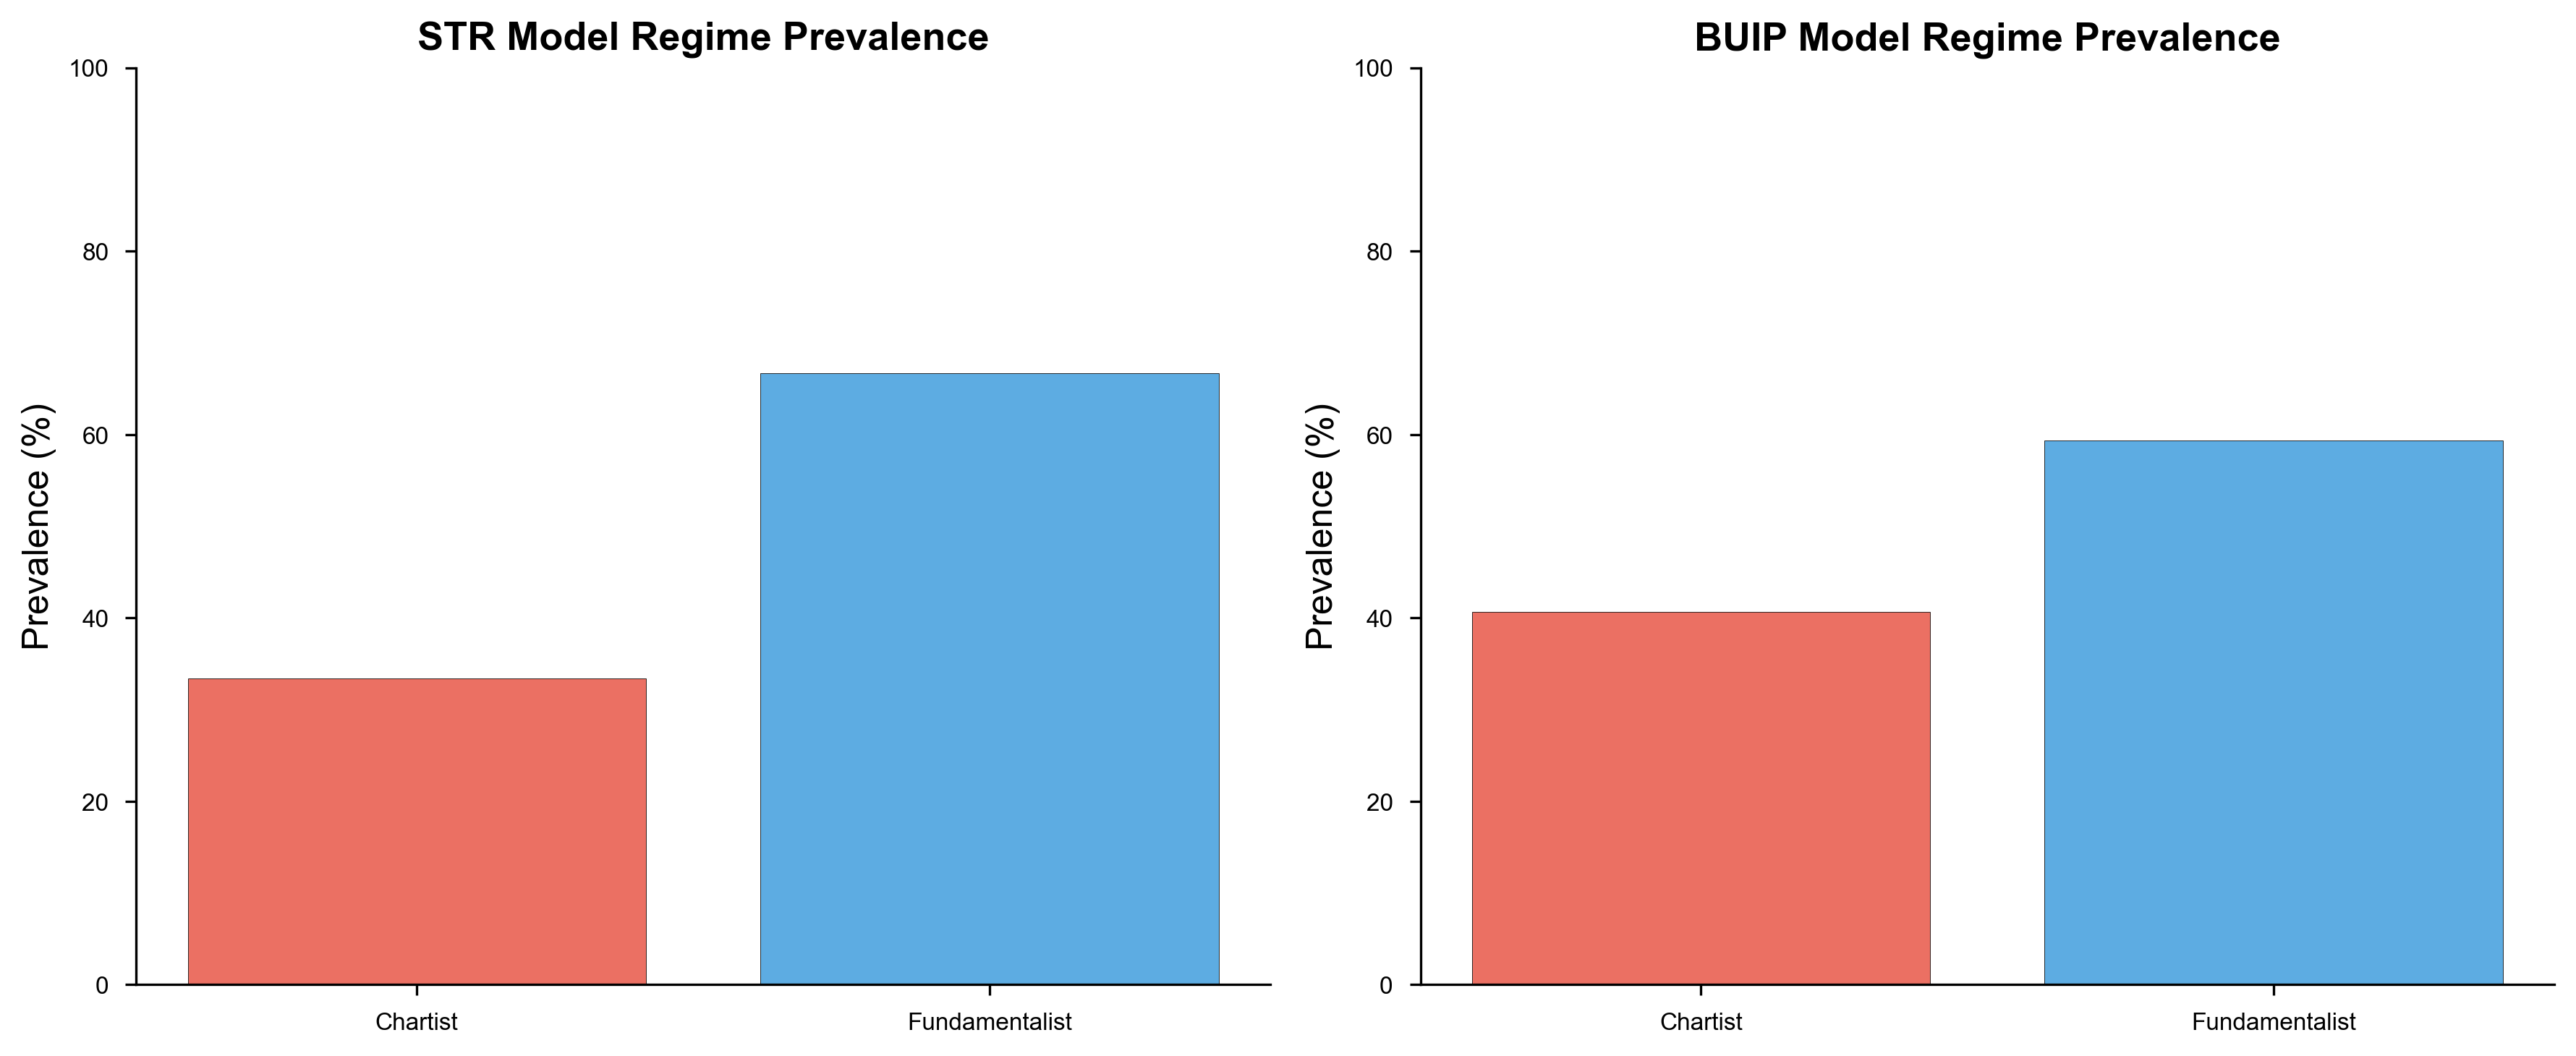

Regime prevalence plot saved

ALL FIGURES SAVED TO: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results


In [20]:
# Aggregate STR regime distribution
all_G_values = []
for country_name, result_dict in str_results.items():
    G = result_dict['result'].G.dropna()
    all_G_values.extend(G.values)

if len(all_G_values) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(all_G_values, bins=50, color='black', alpha=0.7, edgecolor='white')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold (G=0.5)')
    ax.set_xlabel('Transition Function G(z)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('STR Regime Distribution (All Countries)', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_dir / 'str_regime_distribution.png', dpi=300, bbox_inches='tight')
    plt.savefig(output_dir / 'str_regime_distribution.pdf', bbox_inches='tight')
    plt.show()
    print(f"STR distribution plot saved")

# Aggregate BUIP regime distribution
all_omega_values = []
for country_name, result in buip_results.items():
    omega = result.omega.dropna()
    all_omega_values.extend(omega.values)

if len(all_omega_values) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(all_omega_values, bins=50, color='darkblue', alpha=0.7, edgecolor='white')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold (ω=0.5)')
    ax.set_xlabel('Mixing Weight ω', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('BUIP Regime Distribution (All Countries)', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_dir / 'buip_regime_distribution.png', dpi=300, bbox_inches='tight')
    plt.savefig(output_dir / 'buip_regime_distribution.pdf', bbox_inches='tight')
    plt.show()
    print(f"BUIP distribution plot saved")

# Regime prevalence comparison
str_chartist_pct = (np.array(all_G_values) > 0.5).mean() * 100 if len(all_G_values) > 0 else 0
str_fundamentalist_pct = 100 - str_chartist_pct

buip_chartist_pct = (np.array(all_omega_values) < 0.5).mean() * 100 if len(all_omega_values) > 0 else 0
buip_fundamentalist_pct = 100 - buip_chartist_pct

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# STR
ax1.bar(['Chartist', 'Fundamentalist'], [str_chartist_pct, str_fundamentalist_pct], 
        color=['#e74c3c', '#3498db'], alpha=0.8, edgecolor='black')
ax1.set_ylabel('Prevalence (%)', fontsize=12)
ax1.set_title('STR Model Regime Prevalence', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 100)

# BUIP
ax2.bar(['Chartist', 'Fundamentalist'], [buip_chartist_pct, buip_fundamentalist_pct], 
        color=['#e74c3c', '#3498db'], alpha=0.8, edgecolor='black')
ax2.set_ylabel('Prevalence (%)', fontsize=12)
ax2.set_title('BUIP Model Regime Prevalence', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(output_dir / 'regime_prevalence_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'regime_prevalence_comparison.pdf', bbox_inches='tight')
plt.show()
print(f"Regime prevalence plot saved")

print(f"\n{'='*60}")
print("ALL FIGURES SAVED TO:", output_dir)
print(f"{'='*60}")

## 7. Summary Report

In [21]:
print("\n" + "="*80)
print("REPRODUCTION PIPELINE COMPLETE")
print("="*80)

print(f"\nSTR Estimation:")
print(f"  - {len(str_results)} / {len(COUNTRIES)} countries estimated")
print(f"  - Results table: {output_dir / 'str_results_table.csv'}")

print(f"\nBUIP Estimation:")
print(f"  - {len(buip_results)} / {len(COUNTRIES)} countries estimated")
print(f"  - Results table: {output_dir / 'buip_results_table.csv'}")

print(f"\nOutput Files Generated:")
print(f"  - Descriptive statistics: descriptive_statistics.csv")
print(f"  - STR results: str_results_table.csv")
print(f"  - BUIP results: buip_results_table.csv")
print(f"  - STR regime distribution: str_regime_distribution.pdf/.png")
print(f"  - BUIP regime distribution: buip_regime_distribution.pdf/.png")
print(f"  - Regime prevalence comparison: regime_prevalence_comparison.pdf/.png")

print(f"\nAll files saved to: {output_dir}")
print("\n" + "="*80)


REPRODUCTION PIPELINE COMPLETE

STR Estimation:
  - 14 / 14 countries estimated
  - Results table: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/str_results_table.csv

BUIP Estimation:
  - 14 / 14 countries estimated
  - Results table: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results/buip_results_table.csv

Output Files Generated:
  - Descriptive statistics: descriptive_statistics.csv
  - STR results: str_results_table.csv
  - BUIP results: buip_results_table.csv
  - STR regime distribution: str_regime_distribution.pdf/.png
  - BUIP regime distribution: buip_regime_distribution.pdf/.png
  - Regime prevalence comparison: regime_prevalence_comparison.pdf/.png

All files saved to: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results



In [40]:
# Reload module to get latest changes
import importlib
import src.output_figures
importlib.reload(src.output_figures)
from src.output_figures import plot_country_detailed_analysis

# Create detailed plots directory
detailed_plots_dir = output_dir / "detailed_plots"
detailed_plots_dir.mkdir(parents=True, exist_ok=True)

# Generate detailed STR plots for each country
print("\n" + "="*60)
print("GENERATING DETAILED STR PLOTS")
print("="*60)

for country_name in str_results.keys():
    try:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        z_name = result_dict['z_name']
        
        # Get country data to extract transition variable
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        z_candidates = build_z_candidates(country_df)
        z_series = z_candidates[z_name]
        
        # Prepare dependent variable
        y = country_df["r_s"] - (country_df["i_for"] - country_df["i_dom"])
        
        # Generate plot
        plot_country_detailed_analysis(
            y=y,
            transition_var=z_series,
            transition_func=str_result.G,
            c_threshold=str_result.params['c'],
            country=country_name,
            var_name=z_name,
            model_type='STR',
            save_path=detailed_plots_dir / f"{country_name.replace(' ', '_')}_str_detailed.pdf"
        )
        
        print(f"✓ {country_name}: STR detailed plot saved")
        
    except Exception as e:
        print(f"✗ {country_name}: Failed - {e}")

# Generate detailed BUIP plots for each country
print("\n" + "="*60)
print("GENERATING DETAILED BUIP PLOTS")
print("="*60)

for country_name in buip_results.keys():
    try:
        buip_result = buip_results[country_name]
        
        # Get country data
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        buip_df = build_beh_sample(country_df)
        
        # Prepare dependent variable and utility differential
        y = buip_df["y"]
        utility_diff = buip_result.U_f - buip_result.U_c
        
        # Generate plot
        plot_country_detailed_analysis(
            y=y,
            transition_var=utility_diff,
            transition_func=buip_result.omega,
            c_threshold=buip_result.params['c'],
            country=country_name,
            var_name="Utility Differential",
            model_type='BUIP',
            save_path=detailed_plots_dir / f"{country_name.replace(' ', '_')}_buip_detailed.pdf"
        )
        
        print(f"✓ {country_name}: BUIP detailed plot saved")
        
    except Exception as e:
        print(f"✗ {country_name}: Failed - {e}")

print("\n" + "="*60)
print(f"DETAILED PLOTS SAVED TO: {detailed_plots_dir}")
print("="*60)


GENERATING DETAILED STR PLOTS
✓ Australia: STR detailed plot saved
✓ Brazil: STR detailed plot saved
✓ Australia: STR detailed plot saved
✓ Brazil: STR detailed plot saved
✓ Canada: STR detailed plot saved
✓ Euro Area: STR detailed plot saved
✓ Canada: STR detailed plot saved
✓ Euro Area: STR detailed plot saved
✓ Indonesia: STR detailed plot saved
✓ Japan: STR detailed plot saved
✓ Indonesia: STR detailed plot saved
✓ Japan: STR detailed plot saved
✓ Korea: STR detailed plot saved
✓ Mexico: STR detailed plot saved
✓ Korea: STR detailed plot saved
✓ Mexico: STR detailed plot saved
✓ New Zealand: STR detailed plot saved
✓ New Zealand: STR detailed plot saved
✓ Philippines: STR detailed plot saved
✓ Philippines: STR detailed plot saved
✓ Switzerland: STR detailed plot saved
✓ Thailand: STR detailed plot saved
✓ Switzerland: STR detailed plot saved
✓ Thailand: STR detailed plot saved
✓ Türkiye: STR detailed plot saved
✓ United Kingdom: STR detailed plot saved

GENERATING DETAILED BUIP PL

## 8. Additional Publication-Quality Figures

In [33]:
from src.output_figures import (
    plot_regime_distribution,
    plot_regime_timeseries,
    plot_aggregated_regime_prevalence,
    plot_str_transition_function,
    plot_gamma_comparison,
    plot_residual_diagnostics,
    plot_model_comparison
)

# Create publication figures directory
pub_fig_dir = output_dir / "publication" / "figures"
pub_fig_dir.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("GENERATING ADDITIONAL PUBLICATION FIGURES")
print("="*60)


GENERATING ADDITIONAL PUBLICATION FIGURES


### 8.1 STR Transition Functions by Country

In [34]:
# Generate STR transition function plots
print("\n--- STR Transition Functions ---")
for country_name in str_results.keys():
    try:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        z_name = result_dict['z_name']
        
        # Get z series
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        z_candidates = build_z_candidates(country_df)
        z_series = z_candidates[z_name]
        
        # Align with G
        common_idx = str_result.G.index.intersection(z_series.index)
        G_aligned = str_result.G.loc[common_idx]
        z_aligned = z_series.loc[common_idx]
        
        plot_str_transition_function(
            G=G_aligned,
            z=z_aligned,
            country=country_name,
            z_name=z_name,
            save_path=pub_fig_dir / f"{country_name.replace(' ', '_')}_str_transition.pdf"
        )
        print(f"✓ {country_name}: STR transition function")
    except Exception as e:
        print(f"✗ {country_name}: Failed - {e}")


--- STR Transition Functions ---
✓ Australia: STR transition function
✓ Brazil: STR transition function
✓ Australia: STR transition function
✓ Brazil: STR transition function
✓ Canada: STR transition function
✓ Euro Area: STR transition function
✓ Canada: STR transition function
✓ Euro Area: STR transition function
✓ Indonesia: STR transition function
✓ Japan: STR transition function
✓ Indonesia: STR transition function
✓ Japan: STR transition function
✓ Korea: STR transition function
✓ Mexico: STR transition function
✓ Korea: STR transition function
✓ Mexico: STR transition function
✓ New Zealand: STR transition function
✓ Philippines: STR transition function
✓ New Zealand: STR transition function
✓ Philippines: STR transition function
✓ Switzerland: STR transition function
✓ Thailand: STR transition function
✓ Switzerland: STR transition function
✓ Thailand: STR transition function
✓ Türkiye: STR transition function
✓ United Kingdom: STR transition function
✓ Türkiye: STR transition

### 8.2 BUIP Regime Distributions and Time Series

In [35]:
# Generate BUIP regime distribution and time series plots
print("\n--- BUIP Regime Distributions ---")
for country_name in buip_results.keys():
    try:
        buip_result = buip_results[country_name]
        
        # Distribution plot
        plot_regime_distribution(
            omega=buip_result.omega,
            country=country_name,
            save_path=pub_fig_dir / f"{country_name.replace(' ', '_')}_buip_distribution.pdf"
        )
        
        # Time series plot
        plot_regime_timeseries(
            omega=buip_result.omega,
            country=country_name,
            save_path=pub_fig_dir / f"{country_name.replace(' ', '_')}_buip_timeseries.pdf"
        )
        
        print(f"✓ {country_name}: BUIP distribution & time series")
    except Exception as e:
        print(f"✗ {country_name}: Failed - {e}")


--- BUIP Regime Distributions ---
✓ Australia: BUIP distribution & time series
✓ Brazil: BUIP distribution & time series
✓ Canada: BUIP distribution & time series
✓ Brazil: BUIP distribution & time series
✓ Canada: BUIP distribution & time series
✓ Euro Area: BUIP distribution & time series
✓ Indonesia: BUIP distribution & time series
✓ Euro Area: BUIP distribution & time series
✓ Indonesia: BUIP distribution & time series
✓ Japan: BUIP distribution & time series
✓ Korea: BUIP distribution & time series
✓ Japan: BUIP distribution & time series
✓ Korea: BUIP distribution & time series
✓ Mexico: BUIP distribution & time series
✓ New Zealand: BUIP distribution & time series
✓ Mexico: BUIP distribution & time series
✓ New Zealand: BUIP distribution & time series
✓ Philippines: BUIP distribution & time series
✓ Switzerland: BUIP distribution & time series
✓ Philippines: BUIP distribution & time series
✓ Switzerland: BUIP distribution & time series
✓ Thailand: BUIP distribution & time serie

### 8.3 Gamma Comparison Across Countries

In [36]:
# Generate gamma comparison plots
print("\n--- Gamma Comparisons ---")

# STR gamma comparison (need to restructure results for the function)
str_results_formatted = {}
for country_name, result_dict in str_results.items():
    str_results_formatted[country_name] = {
        'status': 'success',
        'result': result_dict['result']
    }

plot_gamma_comparison(
    results=str_results_formatted,
    model_type='STR',
    save_path=pub_fig_dir / "str_gamma_comparison.pdf"
)
print("✓ STR gamma comparison")

# BUIP gamma comparison
buip_results_formatted = {}
for country_name, result in buip_results.items():
    buip_results_formatted[country_name] = {
        'status': 'success',
        'result': result
    }

plot_gamma_comparison(
    results=buip_results_formatted,
    model_type='BUIP',
    save_path=pub_fig_dir / "buip_gamma_comparison.pdf"
)
print("✓ BUIP gamma comparison")


--- Gamma Comparisons ---
✓ STR gamma comparison
✓ BUIP gamma comparison
✓ BUIP gamma comparison


### 8.4 Aggregated Regime Prevalence

In [37]:
# Generate aggregated regime prevalence plot
print("\n--- Aggregated Regime Prevalence ---")

plot_aggregated_regime_prevalence(
    results=buip_results_formatted,
    save_path=pub_fig_dir / "buip_regime_prevalence.pdf"
)
print("✓ BUIP aggregated regime prevalence")


--- Aggregated Regime Prevalence ---
✓ BUIP aggregated regime prevalence
✓ BUIP aggregated regime prevalence


### 8.5 Model Comparison (STR vs BUIP)

In [38]:
# Generate model comparison plot
print("\n--- Model Comparison ---")

plot_model_comparison(
    str_results=str_results_formatted,
    buip_results=buip_results_formatted,
    save_path=pub_fig_dir / "str_buip_comparison.pdf"
)
print("✓ STR vs BUIP model comparison")


--- Model Comparison ---
✓ STR vs BUIP model comparison


### 8.6 Residual Diagnostics

In [39]:
# Generate residual diagnostic plots
print("\n--- Residual Diagnostics (STR) ---")
for country_name in str_results.keys():
    try:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        
        plot_residual_diagnostics(
            resid=str_result.resid,
            country=country_name,
            save_path=pub_fig_dir / f"{country_name.replace(' ', '_')}_str_diagnostics.pdf"
        )
        print(f"✓ {country_name}: STR residual diagnostics")
    except Exception as e:
        print(f"✗ {country_name}: Failed - {e}")

print("\n--- Residual Diagnostics (BUIP) ---")
for country_name in buip_results.keys():
    try:
        buip_result = buip_results[country_name]
        
        plot_residual_diagnostics(
            resid=buip_result.resid,
            country=country_name,
            save_path=pub_fig_dir / f"{country_name.replace(' ', '_')}_buip_diagnostics.pdf"
        )
        print(f"✓ {country_name}: BUIP residual diagnostics")
    except Exception as e:
        print(f"✗ {country_name}: Failed - {e}")

print("\n" + "="*60)
print(f"ALL PUBLICATION FIGURES SAVED TO: {pub_fig_dir}")
print("="*60)


--- Residual Diagnostics (STR) ---
✓ Australia: STR residual diagnostics
✓ Brazil: STR residual diagnostics
✓ Australia: STR residual diagnostics
✓ Brazil: STR residual diagnostics
✓ Canada: STR residual diagnostics
✓ Euro Area: STR residual diagnostics
✓ Canada: STR residual diagnostics
✓ Euro Area: STR residual diagnostics
✓ Indonesia: STR residual diagnostics
✓ Japan: STR residual diagnostics
✓ Indonesia: STR residual diagnostics
✓ Japan: STR residual diagnostics
✓ Korea: STR residual diagnostics
✓ Mexico: STR residual diagnostics
✓ Korea: STR residual diagnostics
✓ Mexico: STR residual diagnostics
✓ New Zealand: STR residual diagnostics
✓ Philippines: STR residual diagnostics
✓ New Zealand: STR residual diagnostics
✓ Philippines: STR residual diagnostics
✓ Switzerland: STR residual diagnostics
✓ Thailand: STR residual diagnostics
✓ Switzerland: STR residual diagnostics
✓ Thailand: STR residual diagnostics
✓ Türkiye: STR residual diagnostics
✓ United Kingdom: STR residual diagnosti

## 9. Final Summary

In [ ]:
print("\n" + "="*80)
print("COMPLETE REPRODUCTION PIPELINE FINISHED")
print("="*80)

print(f"\n📊 ESTIMATION SUMMARY:")
print(f"  • STR Models: {len(str_results)} / {len(COUNTRIES)} countries")
print(f"  • BUIP Models: {len(buip_results)} / {len(COUNTRIES)} countries")

print(f"\n📁 OUTPUT FILES:")
print(f"  • Tables: {output_dir}")
print(f"    - descriptive_statistics.csv")
print(f"    - str_results_table.csv")
print(f"    - buip_results_table.csv")

print(f"\n  • Figures: {output_dir}")
print(f"    - Aggregate distributions (PDF/PNG)")
print(f"    - Regime prevalence comparisons (PDF/PNG)")

print(f"\n  • Detailed Plots: {detailed_plots_dir}")
print(f"    - {len(str_results)} STR country-specific plots")
print(f"    - {len(buip_results)} BUIP country-specific plots")

print(f"\n  • Publication Figures: {pub_fig_dir}")
print(f"    - STR transition functions ({len(str_results)} countries)")
print(f"    - BUIP distributions & time series ({len(buip_results)} countries)")
print(f"    - Gamma comparisons (STR & BUIP)")
print(f"    - Regime prevalence (BUIP)")
print(f"    - Model comparison (STR vs BUIP)")
print(f"    - Residual diagnostics (STR & BUIP, {len(str_results) + len(buip_results)} total)")

print(f"\n✅ All results successfully generated!")
print("="*80)